<div align="center">

# Load and Plot EEG Files

</div>

> This file serves the purpose of checking how to load and plot the EEG files

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

# 1. Simple function to load and plot

In [2]:
def load_h5(path):
    with h5py.File(path, "r") as f:
        signals = f["signals"][:]
        fs = f["sampling_rate"][()]
        ch_names = f["channel_names"][:]
        intervals = f["seizure_intervals"][:] if "seizure_intervals" in f else np.array([])
        
    ch_names = [
        c.decode() if isinstance(c, (bytes, bytearray)) else c
        for c in ch_names
    ]
    return signals, fs, ch_names, intervals

In [3]:
path = "../Data/chb07_19.h5"
signals, fs, ch_names, intervals = load_h5(path)

print(signals.shape)
print(fs)
print(ch_names)
print(intervals)

(18, 3689216)
256.0
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ']
[[3504128 3540736]]


# 2. Function to plot EEG Signals

In [27]:

def plot_eeg(
    signals,
    fs,
    ch_names=None,
    intervals=None,
    channels=None,        # list of indices OR names
    t_start=None,         # in seconds
    t_end=None,           # in seconds
    figsize=(15, 8),
    color_mode=None,
    seizure_color= '#bfd630',
    seizure_alpha = 0.4,
    title = 'EEG Signals',
    linewidth=1
):
    """
    Flexible EEG plotter.

    Parameters:
    - signals: (n_channels, n_samples)
    - fs: sampling frequency
    - ch_names: list of channel names
    - intervals: seizure intervals (samples or seconds)
    - channels: list of channel indices OR names to plot
    - t_start, t_end: time window in seconds
    - figsize: figure size
    """

    # --- Channel selection ---
    if channels is not None:
        if isinstance(channels[0], str):
            idx = [ch_names.index(ch) for ch in channels]
        else:
            idx = channels
        signals = signals[idx]
        if ch_names is not None:
            ch_names = [ch_names[i] for i in idx]

    n_channels, n_samples = signals.shape

    # --- Time window selection ---
    if t_start is None:
        t_start = 0
    if t_end is None:
        t_end = n_samples / fs

    start_sample = int(t_start * fs)
    end_sample = int(t_end * fs)

    signals = signals[:, start_sample:end_sample]
    t = np.arange(start_sample, end_sample) / fs



    # Color
    # --- COLOR SETUP ---
    if color_mode == "tab10":
        colors = plt.cm.tab10(np.linspace(0, 1, n_channels))
    elif color_mode == "viridis":
        colors = plt.cm.viridis(np.linspace(0, 1, n_channels))
    else:
        colors = ["#3498eb"] * n_channels

        
    # --- Plot ---
    plt.figure(figsize=figsize)

    spacing = np.max(np.abs(signals)) * 2
    offset = 0

    yticks = []
    ylabels = []

    for i in range(n_channels):
        plt.plot(t, signals[i] + offset, color=colors[i], linewidth=linewidth)
        yticks.append(offset)
        if ch_names is not None:
            ylabels.append(ch_names[i])
        else:
            ylabels.append(f"Ch {i}")
        offset += spacing
    
    plt.yticks(yticks, ylabels)


    # --- Seizure highlighting (FIXED) ---
    if intervals is not None:
        intervals = np.array(intervals)

        if intervals.size > 0:
            if intervals.ndim == 1:
                intervals = intervals.reshape(1, -1)

            for start, end in intervals:

                # --- ALWAYS convert to seconds ---
                start = start / fs
                end = end / fs

                # --- check overlap with window ---
                if end >= t_start and start <= t_end:

                    # --- clip to visible region ---
                    start_clip = max(start, t_start)
                    end_clip = min(end, t_end)

                    plt.axvspan(start_clip, end_clip, color=seizure_color, alpha=seizure_alpha)

    plt.xlabel("Time (s)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

## 3. Plots

## 3.1 Change Figure Size

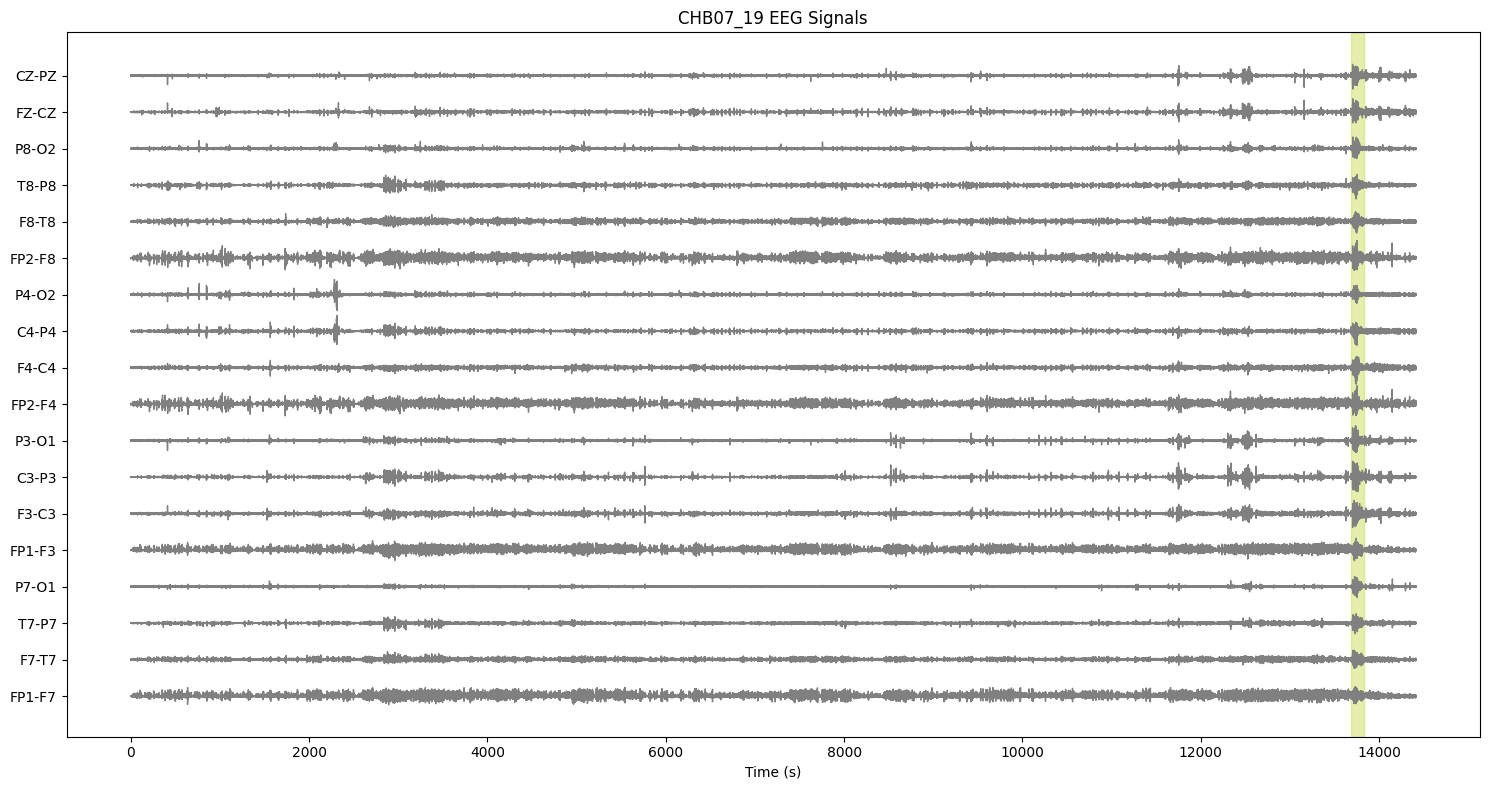

In [7]:
plot_eeg(signals, fs, ch_names, intervals=intervals,figsize=(15, 8),)

## 3.2 Plot Specific Channels

In [ ]:
lot_eeg(
    signals,
    fs,
    ch_names=None,
    intervals=None,
    channels=None,        # list of indices OR names
    t_start=None,         # in seconds
    t_end=None,           # in seconds
    figsize=(15, 8),
    color_mode=None,
    seizure_color= '#bfd630',
    seizure_alpha = 0.4,
    title = 'EEG Signals',
    linewidth=1
)

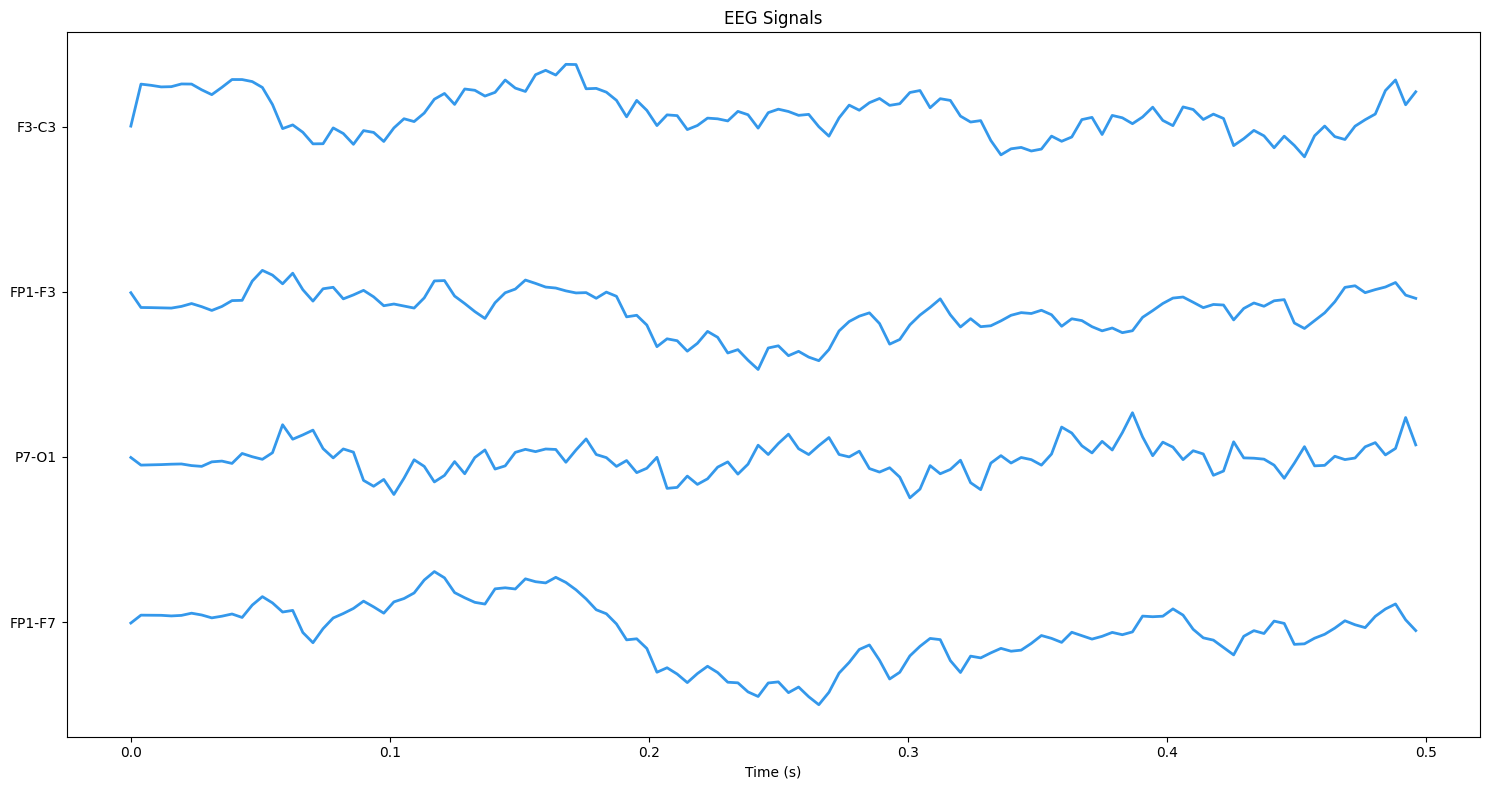

In [28]:
plot_eeg(signals, fs, ch_names, intervals, channels=[0, 3,4, 5], linewidth=2, t_start=0, t_end=0.5)

## 3.3 Plot Different Time Interval

## 3.4 Change Colors

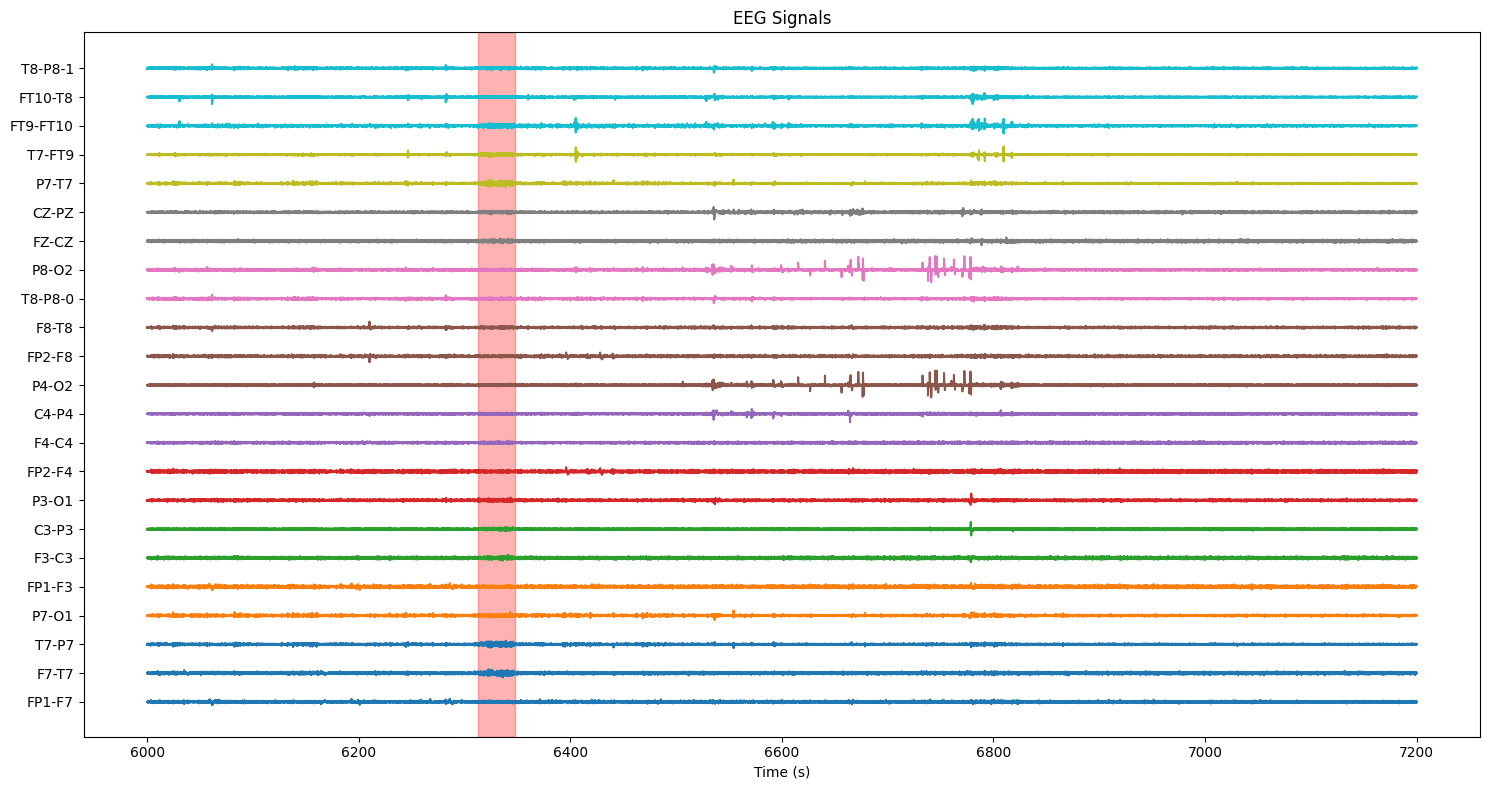

In [36]:
plot_eeg(signals, fs, ch_names, intervals=intervals,t_start= 6000, color_mode='tab10',seizure_color='red', seizure_alpha=0.3)

# 3. Functions relating to txt files

## 3.1 Check for existing Seizure Files

In [ ]:
from pathlib import Path

# paths
records_file = "RECORDS-WITH-SEIZURES-H5.txt"
features_dir = Path("Features/Seizure/")

# read seizure records
with open(records_file, "r") as f:
    records = [line.strip().replace(".h5", "") for line in f if line.strip()]

print("Checking feature files...\n")

missing = []

for rec in records:
    feature_file = features_dir / f"{rec}_seizure.mat"

    if feature_file.exists():
        print(f"FOUND   : {feature_file.name}")
    else:
        print(f"MISSING : {feature_file.name}")
        missing.append(rec)

print("\nSummary")
print(f"Total records : {len(records)}")
print(f"Found         : {len(records) - len(missing)}")
print(f"Missing       : {len(missing)}")

if missing:
    print("\nMissing records:")
    for rec in missing:
        print(rec)

In [ ]:
# Read files
with open("RECORDS-H5.txt", "r") as f:
    all_records = {line.strip() for line in f if line.strip()}

with open("RECORDS-WITH-SEIZURES-H5.txt", "r") as f:
    seizure_records = {line.strip() for line in f if line.strip()}

# Records without seizures
non_seizure_records = sorted(all_records - seizure_records)

# Save to file
with open("RECORDS-WITHOUT-SEIZURES-H5.txt", "w") as f:
    for record in non_seizure_records:
        f.write(record + "\n")

print(f"Saved {len(non_seizure_records)} records to RECORDS-WITHOUT-SEIZURES-H5.txt")

## 5.2 Check for existing Non-seizure Files

In [6]:
from pathlib import Path

# paths
records_file = "RECORDS-WITHOUT-SEIZURES-H5.txt"
features_dir = Path("Features/Non_Seizure/")

# read seizure records
with open(records_file, "r") as f:
    records = [line.strip().replace(".h5", "") for line in f if line.strip()]

print("Checking feature files...\n")

missing = []

for rec in records:
    feature_file = features_dir / f"{rec}_features.mat"

    if feature_file.exists():
        print(f"FOUND   : {feature_file.name}")
    else:
        print(f"MISSING : {feature_file.name}")
        missing.append(rec)

print("\nSummary")
print(f"Total records : {len(records)}")
print(f"Found         : {len(records) - len(missing)}")
print(f"Missing       : {len(missing)}")

if missing:
    print("\nMissing records:")
    for rec in missing:
        print(rec)

Checking feature files...

FOUND   : chb01_01_features.mat
FOUND   : chb01_02_features.mat
FOUND   : chb01_05_features.mat
FOUND   : chb01_06_features.mat
FOUND   : chb01_07_features.mat
FOUND   : chb01_08_features.mat
FOUND   : chb01_09_features.mat
FOUND   : chb01_10_features.mat
FOUND   : chb01_11_features.mat
FOUND   : chb01_12_features.mat
FOUND   : chb01_13_features.mat
FOUND   : chb01_14_features.mat
FOUND   : chb01_17_features.mat
FOUND   : chb01_19_features.mat
FOUND   : chb01_20_features.mat
FOUND   : chb01_22_features.mat
FOUND   : chb01_23_features.mat
FOUND   : chb01_24_features.mat
FOUND   : chb01_25_features.mat
FOUND   : chb01_27_features.mat
FOUND   : chb01_29_features.mat
FOUND   : chb01_30_features.mat
FOUND   : chb01_31_features.mat
FOUND   : chb01_32_features.mat
FOUND   : chb01_33_features.mat
FOUND   : chb01_34_features.mat
FOUND   : chb01_36_features.mat
FOUND   : chb01_37_features.mat
FOUND   : chb01_38_features.mat
FOUND   : chb01_39_features.mat
FOUND   : chb

In [ ]:
from pathlib import Path

# paths
records_file = "RECORDS-WITHOUT-SEIZURES-H5.txt"
features_dir = Path("Features/Non_Seizure/")

# expected records
with open(records_file, "r") as f:
    records = [line.strip().replace(".h5", "") for line in f if line.strip()]

expected_files = {f"{rec}_features.mat" for rec in records}

print("Checking feature files...\n")

missing = []

for rec in records:
    feature_file = features_dir / f"{rec}_features.mat"

    if feature_file.exists():
        print(f"FOUND   : {feature_file.name}")
    else:
        print(f"MISSING : {feature_file.name}")
        missing.append(rec)

# actual files in folder
actual_files = {
    f.name for f in features_dir.glob("*_features.mat")
}

# extras
extra_files = actual_files - expected_files

print("\nSummary")
print(f"Expected records : {len(records)}")
print(f"Found            : {len(records) - len(missing)}")
print(f"Missing          : {len(missing)}")

print(f"\nFiles in folder  : {len(actual_files)}")
print(f"Extra files      : {len(extra_files)}")


if missing:
    print("\nMissing records:")
    for rec in missing:
        print(rec)

if extra_files:
    print("\nExtra feature files:")
    for f in sorted(extra_files):
        print(f)

## 5. Change Annotations

In [18]:
from pathlib import Path
import numpy as np
import h5py

# =====================================================
# LOAD FUNCTION (your version, kept clean)
# =====================================================
def load_h5(path):
    with h5py.File(path, "r") as f:
        signals = f["signals"][:]
        fs = f["sampling_rate"][()]
        ch_names = f["channel_names"][:]
        intervals = f["seizure_intervals"][:] if "seizure_intervals" in f else np.array([])

    ch_names = [
        c.decode() if isinstance(c, (bytes, bytearray)) else c
        for c in ch_names
    ]

    return signals, fs, ch_names, intervals


# =====================================================
# PATHS
# =====================================================
feature_dir = Path("../Data")
records_file = "RECORDS-WITH-SEIZURES-H5.txt"

# =====================================================
# READ FILE LIST
# =====================================================
with open(records_file, "r") as f:
    files = [line.strip() for line in f if line.strip()]

paths = [feature_dir / f for f in files]

print(f"Total files: {len(paths)}\n")


# =====================================================
# LOOP THROUGH FILES
# =====================================================
summary = []

for path in paths:
    signals, fs, ch_names, intervals = load_h5(path)

    print("=" * 60)
    print("File:", path.name)
    print("Signals shape:", signals.shape)
    print("Sampling rate:", fs)
    print("Channels:", len(ch_names))

    # -------------------------
    # seizure intervals handling
    # -------------------------
    if intervals.size == 0:
        print("Seizure intervals: NONE")
        n_seizures = 0
    else:
        print("Seizure intervals:")
        for i, (start, end) in enumerate(intervals):
            duration = end - start
            print(f"  Seizure {i+1}: {start:.1f}s → {end:.1f}s ({duration:.1f}s)")
        n_seizures = len(intervals)

    summary.append({
        "file": path.name,
        "n_seizures": n_seizures,
        "n_channels": len(ch_names),
        "n_samples": signals.shape[1] if signals.ndim > 1 else signals.shape[0],
        "fs": fs
    })


# =====================================================
# FINAL SUMMARY
# =====================================================
print("\n\n================ SUMMARY ================\n")

for s in summary:
    print(f"{s['file']}: seizures={s['n_seizures']}, "
          f"channels={s['n_channels']}, fs={s['fs']}")

Total files: 138

File: chb01_03.h5
Signals shape: (18, 921600)
Sampling rate: 256.0
Channels: 18
Seizure intervals:
  Seizure 1: 766976.0s → 777216.0s (10240.0s)
File: chb01_04.h5
Signals shape: (18, 921600)
Sampling rate: 256.0
Channels: 18
Seizure intervals:
  Seizure 1: 375552.0s → 382464.0s (6912.0s)
File: chb01_15.h5
Signals shape: (18, 921600)
Sampling rate: 256.0
Channels: 18
Seizure intervals:
  Seizure 1: 443392.0s → 453632.0s (10240.0s)
File: chb01_16.h5
Signals shape: (18, 921600)
Sampling rate: 256.0
Channels: 18
Seizure intervals:
  Seizure 1: 259840.0s → 272896.0s (13056.0s)
File: chb01_18.h5
Signals shape: (18, 921600)
Sampling rate: 256.0
Channels: 18
Seizure intervals:
  Seizure 1: 440320.0s → 463360.0s (23040.0s)
File: chb01_21.h5
Signals shape: (18, 921600)
Sampling rate: 256.0
Channels: 18
Seizure intervals:
  Seizure 1: 83712.0s → 107520.0s (23808.0s)
File: chb01_26.h5
Signals shape: (18, 595200)
Sampling rate: 256.0
Channels: 18
Seizure intervals:
  Seizure 1: 47

In [23]:
from pathlib import Path
import numpy as np
import pandas as pd
import h5py

feature_dir = Path("../Data")
records_file = "RECORDS-WITH-SEIZURES-H5.txt"


def load_h5(path):
    with h5py.File(path, "r") as f:
        intervals = f["seizure_intervals"][:] if "seizure_intervals" in f else np.array([])
        fs = f["sampling_rate"][()]
    return intervals, fs


with open(records_file, "r") as f:
    files = [line.strip() for line in f if line.strip()]

rows = []

for fname in files:
    path = feature_dir / fname
    intervals, fs = load_h5(path)

    if intervals.size == 0:
        continue

    file_id = fname.replace(".h5", "")   # ✅ remove extension

    for i, (start, end) in enumerate(intervals):
        rows.append({
            "file": file_id,
            "seizure_id": i + 1,

            # RAW (for ML)
            "start_sample": int(start),
            "end_sample": int(end),

            # CONVERTED (for interpretation)
            "start_sec": float(start / fs),
            "end_sec": float(end / fs),
            "duration_sec": float((end - start) / fs),
        })


df = pd.DataFrame(rows)
df.to_csv("seizure_annotations_full.csv", index=False)

print("Saved: seizure_annotations_full.csv")
print(df.head())

Saved: seizure_annotations_full.csv
       file  seizure_id  start_sample  end_sample  start_sec  end_sec  \
0  chb01_03           1        766976      777216     2996.0   3036.0   
1  chb01_04           1        375552      382464     1467.0   1494.0   
2  chb01_15           1        443392      453632     1732.0   1772.0   
3  chb01_16           1        259840      272896     1015.0   1066.0   
4  chb01_18           1        440320      463360     1720.0   1810.0   

   duration_sec  
0          40.0  
1          27.0  
2          40.0  
3          51.0  
4          90.0  
